# We will use this notebook as an example to look at some Argo data


### First, let's load in some packages - this is a function I have made in python to download Argo data - just run it and it should be fine 

In [1]:
# Import packages
import os              # For file path handling
import time            # For sleep during retry logic
import shutil          # For copying downloaded content
import requests        # For HTTP downloads
import urllib3         # For disabling SSL warnings
import numpy as np     # For logical operations and array handling
import pandas as pd    # For reading and manipulating the GDAC index
from datetime import datetime  # For date filtering
import xarray as xr 




# Function to download and parse GDAC synthetic profile index file ## Should work with core argo 
def argo_gdac(lat_range=None,lon_range=None,start_date=None,end_date=None,sensors=None,floats=None,
              overwrite_index=False,overwrite_profiles=False,skip_download=False,
              download_individual_profs=False,save_to=None,verbose=True):
  """ Downloads GDAC Sprof index file, then selects float profiles based on criteria.
      Either returns information on profiles and floats (if skip_download=True) or downloads them (if False).

      Arguments:
          lat_range: None, to select all latitudes
                     or [lower, upper] within -90 to 90 (selection is inclusive)
          lon_range: None, to select all longitudes
                     or [lower, upper] within either -180 to 180 or 0 to 360 (selection is inclusive)
                     NOTE: longitude range is allowed to cross -180/180 or 0/360
          start_date: None or datetime object
          end_date:   None or datetime object
          sensors: None, to select profiles with any combination of sensors
                   or string or list of strings to specify required sensors
                   > note that common options include PRES, TEMP, PSAL, DOXY, CHLA, BBP700,
                                                      PH_IN_SITU_TOTAL, and NITRATE
          floats: None, to select any floats matching other criteria
                  or int or list of ints specifying floats' WMOID numbers
          overwrite_index: False to keep existing downloaded GDAC index file, or True to download new index
          overwrite_profiles: False to keep existing downloaded profile files, or True to download new files
          skip_download: True to skip download and return: (<list of WMOIDs>, <DataFrame of index file subset>,
                                                            <list of downloaded filenames [if applicable]>)
                         or False to download those profiles
          download_individual_profs: False to download single Sprof file containing all profiles for each float
                                     or True to download individual profile files for each float
          save_to: None to download to Google Drive "/GO-BGC Workshop/Profiles" directory
                   or string to specify directory path for profile downloads
          verbose: True to announce progress, or False to stay silent

  """
  # Paths
  url_root = 'https://www.usgodae.org/ftp/outgoing/argo/'
  dac_url_root = url_root + 'dac/'
  index_filename = 'argo_synthetic-profile_index.txt'
  if save_to is None: save_to = root

  # Download GDAC synthetic profile index file
  download_file(url_root,index_filename,overwrite=overwrite_index)

  # Load index file into Pandas DataFrame
  index_file_path = os.path.join(root, index_filename)
  gdac_index = pd.read_csv(index_file_path, delimiter=',', header=8, parse_dates=['date','date_update'], date_parser=lambda x: pd.to_datetime(x,format='%Y%m%d%H%M%S'))


  # Establish time and space criteria
  if lat_range is None:  lat_range = [-90.0,90.0]
  if lon_range is None:  lon_range = [-180.0,180.0]
  elif lon_range[0] > 180 or lon_range[1] > 180:
    if lon_range[0] > 180: lon_range[0] -= 360
    if lon_range[1] > 180: lon_range[1] -= 360
  if start_date is None: start_date = datetime(1900,1,1)
  if end_date is None:   end_date = datetime(2200,1,1)

  float_wmoid_regexp = r'[a-z]*/[0-9]*/profiles/[A-Z]*([0-9]*)_[0-9]*[A-Z]*.nc'
  gdac_index['wmoid'] = gdac_index['file'].str.extract(float_wmoid_regexp).astype(int)
  filepath_main_regexp = '([a-z]*/[0-9]*/)profiles/[A-Z]*[0-9]*_[0-9]*[A-Z]*.nc'
  gdac_index['filepath_main'] = gdac_index['file'].str.extract(filepath_main_regexp)
  filepath_regexp = '([a-z]*/[0-9]*/profiles/)[A-Z]*[0-9]*_[0-9]*[A-Z]*.nc'
  gdac_index['filepath'] = gdac_index['file'].str.extract(filepath_regexp)
  filename_regexp = '[a-z]*/[0-9]*/profiles/([A-Z]*[0-9]*_[0-9]*[A-Z]*.nc)'
  gdac_index['filename'] = gdac_index['file'].str.extract(filename_regexp)

  # Subset profiles based on time and space criteria
  gdac_index_subset = gdac_index.loc[np.logical_and.reduce([gdac_index['latitude'] >= lat_range[0],
                                                            gdac_index['latitude'] <= lat_range[1],
                                                            gdac_index['date'] >= start_date,
                                                            gdac_index['date'] <= end_date]),:]
  if lon_range[1] >= lon_range[0]:    # range does not cross -180/180 or 0/360
    gdac_index_subset = gdac_index_subset.loc[np.logical_and(gdac_index_subset['longitude'] >= lon_range[0],
                                                             gdac_index_subset['longitude'] <= lon_range[1])]
  elif lon_range[1] < lon_range[0]:   # range crosses -180/180 or 0/360
    gdac_index_subset = gdac_index_subset.loc[np.logical_or(gdac_index_subset['longitude'] >= lon_range[0],
                                                            gdac_index_subset['longitude'] <= lon_range[1])]

  # If requested, subset profiles using float WMOID criteria
  if floats is not None:
    if type(floats) is not list: floats = [floats]
    gdac_index_subset = gdac_index_subset.loc[gdac_index_subset['wmoid'].isin(floats),:]

  # If requested, subset profiles using sensor criteria
  if sensors is not None:
    if type(sensors) is not list: sensors = [sensors]
    for sensor in sensors:
      gdac_index_subset = gdac_index_subset.loc[gdac_index_subset['parameters'].str.contains(sensor),:]

  # Examine subsetted profiles
  wmoids = gdac_index_subset['wmoid'].unique()
  wmoid_filepaths = gdac_index_subset['filepath_main'].unique()

  # Just return list of floats and DataFrame with subset of index file, or download each profile
  if not skip_download:
    downloaded_filenames = []
    if download_individual_profs:
      for p_idx in gdac_index_subset.index:
        download_file(dac_url_root + gdac_index_subset.loc[p_idx]['filepath'],
                      gdac_index_subset.loc[p_idx]['filename'],
                      save_to=save_to,overwrite=overwrite_profiles,verbose=verbose)
        downloaded_filenames.append(gdac_index_subset.loc[p_idx]['filename'])
    else:
      for f_idx, wmoid_filepath in enumerate(wmoid_filepaths):
        download_file(dac_url_root + wmoid_filepath,str(wmoids[f_idx]) + '_Sprof.nc',
                      save_to=save_to,overwrite=overwrite_profiles,verbose=verbose)
        downloaded_filenames.append(str(wmoids[f_idx]) + '_Sprof.nc')
    return wmoids, gdac_index_subset, downloaded_filenames
  else:
    return wmoids, gdac_index_subset

# Function to download a single file
def download_file(url_path,filename,save_to=None,overwrite=False,verbose=True):
    """ Downloads and saves a file from a given URL using HTTP protocol.

    Note: If '404 file not found' error returned, function will return without downloading anything.
    
    Arguments:
        url_path: root URL to download from including trailing slash ('/')
        filename: filename to download including suffix
        save_to: None (to download to root Google Drive GO-BGC directory)
                 or directory path
        overwrite: False to leave existing files in place
                   or True to overwrite existing files
        verbose: True to announce progress
                 or False to stay silent
    
    """
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    if save_to is None:
      save_to = root

    try:
      if filename in os.listdir(save_to):
          if not overwrite:
              if verbose: print('>>> File ' + filename + ' already exists. Leaving current version.')
              return
          else:
              if verbose: print('>>> File ' + filename + ' already exists. Overwriting with new version.')

      def get_func(url,stream=True):
          try:
              return requests.get(url,stream=stream,auth=None,verify=False)
          except requests.exceptions.ConnectionError as error_tag:
              print('Error connecting:',error_tag)
              time.sleep(1)
              return get_func(url,stream=stream)

      response = get_func(url_path + filename,stream=True)

      if response.status_code == 404:
          if verbose: print('>>> File ' + filename + ' returned 404 error during download.')
          return
      with open(save_to + filename,'wb') as out_file:
          shutil.copyfileobj(response.raw,out_file)
      del response
      if verbose: print('>>> Successfully downloaded ' + filename + '.')

    except:
      if verbose: print('>>> An error occurred while trying to download ' + filename + '.')
        


# The first float we want to look at is float 5906221

In [2]:
os.chdir(r'C:\Users\jkwyatt\Downloads') #Will need to change this 

In [3]:
save_directory = r'argo_profiles/'  # this will make a new folder called argo profiles in your directory and save the data there
root = r'argo_profiles/'
# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

wmoids, gdac_subset, downloaded_files = argo_gdac(
    floats=[5906221],              # Float ID
    skip_download=False,           # Actually download the files
    download_individual_profs=True, # Download individual profiles (not one big Sprof file)
    save_to=save_directory,         # Save location
    verbose=True                    # Print status updates
)

>>> Successfully downloaded argo_synthetic-profile_index.txt.


C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_9000\516380747.py:59: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  gdac_index = pd.read_csv(index_file_path, delimiter=',', header=8, parse_dates=['date','date_update'], date_parser=lambda x: pd.to_datetime(x,format='%Y%m%d%H%M%S'))


>>> Successfully downloaded SD5906221_001.nc.
>>> Successfully downloaded SD5906221_002.nc.
>>> Successfully downloaded SD5906221_003.nc.
>>> Successfully downloaded SD5906221_004.nc.
>>> Successfully downloaded SD5906221_005.nc.
>>> Successfully downloaded SD5906221_006.nc.
>>> Successfully downloaded SD5906221_007.nc.
>>> Successfully downloaded SD5906221_008.nc.
>>> Successfully downloaded SD5906221_009.nc.
>>> Successfully downloaded SD5906221_010.nc.
>>> Successfully downloaded SD5906221_011.nc.
>>> Successfully downloaded SD5906221_012.nc.
>>> Successfully downloaded SD5906221_013.nc.
>>> Successfully downloaded SD5906221_014.nc.
>>> Successfully downloaded SD5906221_015.nc.
>>> Successfully downloaded SD5906221_016.nc.
>>> Successfully downloaded SD5906221_017.nc.
>>> Successfully downloaded SD5906221_018.nc.
>>> Successfully downloaded SD5906221_019.nc.
>>> Successfully downloaded SD5906221_020.nc.
>>> Successfully downloaded SD5906221_021.nc.
>>> Successfully downloaded SD5906

# Now we want to load all these profiles into one dataset

In [4]:
import pandas as pd
from tqdm import tqdm

# Define bin edges for pressure
bin_edges = np.arange(0, 2005, 5)  # 5 dbar bins up to 2000 dbar

# Function to bin data
def bin_data(data, pressure, bin_edges):
    # Drop completely missing data
    mask = np.isfinite(pressure) & np.isfinite(data)
    data = data.where(mask)
    pressure = pressure.where(mask)
    return data.groupby_bins(pressure, bin_edges).mean(dim="N_LEVELS", skipna=True)

# Lists to store binned data
nitrate_binned_list = []
doxy_binned_list = []
psal_binned_list = []
temp_binned_list = []
lat_list = []
lon_list = []
time_list = []

# Folder and file list
save_directory = r'argo_profiles/'  ###################### ADJUST THIS #########################
files = sorted([f for f in os.listdir(save_directory) if f.endswith('.nc')])

for filepath in tqdm(files, desc="Processing Argo profiles"):
    try:
        file_full_path = os.path.join(save_directory, filepath)
        ds = xr.open_dataset(file_full_path)

        n_prof = ds.dims.get('N_PROF', 1)  # Default to 1 if missing

        for i in range(n_prof):
            try:
                # Extract variables
                psal = ds.get('PSAL_ADJUSTED', ds.get('PSAL')).isel(N_PROF=i)
                temp = ds.get('TEMP_ADJUSTED', ds.get('TEMP')).isel(N_PROF=i)
                pressure = ds.get('PRES_ADJUSTED', ds.get('PRES')).isel(N_PROF=i)
                nitrate = ds.get('NITRATE_ADJUSTED', None)
                doxy = ds.get('DOXY_ADJUSTED', None)

                if nitrate is not None:
                    nitrate = nitrate.isel(N_PROF=i)
                if doxy is not None:
                    doxy = doxy.isel(N_PROF=i)

                # Skip profiles without deep data
                if pressure.max(skipna=True).values < 1000:
                    continue

                # Skip if temp or psal all NaNs
                if np.isnan(temp).all() or np.isnan(psal).all():
                    continue

                # Metadata
                lat = ds.LATITUDE.isel(N_PROF=i).values
                lon = ds.LONGITUDE.isel(N_PROF=i).values
                time = ds.JULD.isel(N_PROF=i).values

                # Convert time
                if np.issubdtype(time.dtype, np.datetime64):
                    time = time.astype('datetime64[s]').astype(float)
                else:
                    time = pd.to_datetime(str(time)).to_datetime64().astype('datetime64[s]').astype(float)

                # Bin data
                binned_data = {
                    'psal': bin_data(psal, pressure, bin_edges),
                    'temp': bin_data(temp, pressure, bin_edges),
                    'nitrate': bin_data(nitrate, pressure, bin_edges) if nitrate is not None else None,
                    'doxy': bin_data(doxy, pressure, bin_edges) if doxy is not None else None,
                }

                # Append
                psal_binned_list.append(binned_data['psal'])
                temp_binned_list.append(binned_data['temp'])
                if binned_data['nitrate'] is not None:
                    nitrate_binned_list.append(binned_data['nitrate'])
                if binned_data['doxy'] is not None:
                    doxy_binned_list.append(binned_data['doxy'])

                lat_list.append(np.array([lat]))
                lon_list.append(np.array([lon]))
                time_list.append(np.array([time]))

            except Exception as e:
                print(f"Skipping profile {i} in {filepath} due to error: {e}")

    except Exception as e:
        print(f"Skipping file {filepath} due to error: {e}")

# --- Build Dataset ---
binned_ds = xr.Dataset({
    'psal': xr.concat(psal_binned_list, dim='N_PROF'),
    'temp': xr.concat(temp_binned_list, dim='N_PROF'),
    'latitude': ('N_PROF', np.concatenate(lat_list)),
    'longitude': ('N_PROF', np.concatenate(lon_list)),
    'time': ('N_PROF', np.concatenate(time_list))
})

# Optional: Only add nitrate/doxy if they exist
if nitrate_binned_list:
    binned_ds['nitrate'] = xr.concat(nitrate_binned_list, dim='N_PROF')
if doxy_binned_list:
    binned_ds['doxy'] = xr.concat(doxy_binned_list, dim='N_PROF')

# Fix time
epoch = np.datetime64('1970-01-01T00:00:00Z')
binned_ds['time'] = ('N_PROF', epoch + np.array(binned_ds['time'].values, dtype='timedelta64[s]'))

pres_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

binned_ds = binned_ds.assign_coords({
    "PRES_ADJUSTED_bins": pres_bin_centers
})

print("Processing complete!")
print(binned_ds)


Processing Argo profiles: 100%|██████████| 187/187 [00:25<00:00,  7.26it/s]


Processing complete!
<xarray.Dataset>
Dimensions:             (PRES_ADJUSTED_bins: 400, N_PROF: 187)
Coordinates:
  * PRES_ADJUSTED_bins  (PRES_ADJUSTED_bins) float64 2.5 7.5 ... 1.998e+03
Dimensions without coordinates: N_PROF
Data variables:
    psal                (N_PROF, PRES_ADJUSTED_bins) float32 34.1 34.1 ... 34.71
    temp                (N_PROF, PRES_ADJUSTED_bins) float32 9.547 ... 0.9603
    latitude            (N_PROF) float64 -46.01 -46.77 -47.86 ... -61.5 -61.68
    longitude           (N_PROF) float64 85.62 85.84 87.67 ... 146.7 147.1 147.9
    time                (N_PROF) datetime64[ns] 2020-02-16T03:27:58 ... 2025-...
    nitrate             (N_PROF, PRES_ADJUSTED_bins) float32 nan 13.87 ... 32.06
    doxy                (N_PROF, PRES_ADJUSTED_bins) float32 nan 283.6 ... 202.5


C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_9000\4054710106.py:110: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  epoch = np.datetime64('1970-01-01T00:00:00Z')
C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_9000\4054710106.py:111: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  binned_ds['time'] = ('N_PROF', epoch + np.array(binned_ds['time'].values, dtype='timedelta64[s]'))
C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_9000\4054710106.py:111: UserWarning: Converting non-nanosecond precision datetime values to nanosecond p

In [5]:
binned_ds

<xarray.Dataset>
Dimensions:             (PRES_ADJUSTED_bins: 400, N_PROF: 187)
Coordinates:
  * PRES_ADJUSTED_bins  (PRES_ADJUSTED_bins) float64 2.5 7.5 ... 1.998e+03
Dimensions without coordinates: N_PROF
Data variables:
    psal                (N_PROF, PRES_ADJUSTED_bins) float32 34.1 34.1 ... 34.71
    temp                (N_PROF, PRES_ADJUSTED_bins) float32 9.547 ... 0.9603
    latitude            (N_PROF) float64 -46.01 -46.77 -47.86 ... -61.5 -61.68
    longitude           (N_PROF) float64 85.62 85.84 87.67 ... 146.7 147.1 147.9
    time                (N_PROF) datetime64[ns] 2020-02-16T03:27:58 ... 2025-...
    nitrate             (N_PROF, PRES_ADJUSTED_bins) float32 nan 13.87 ... 32.06
    doxy                (N_PROF, PRES_ADJUSTED_bins) float32 nan 283.6 ... 202.5

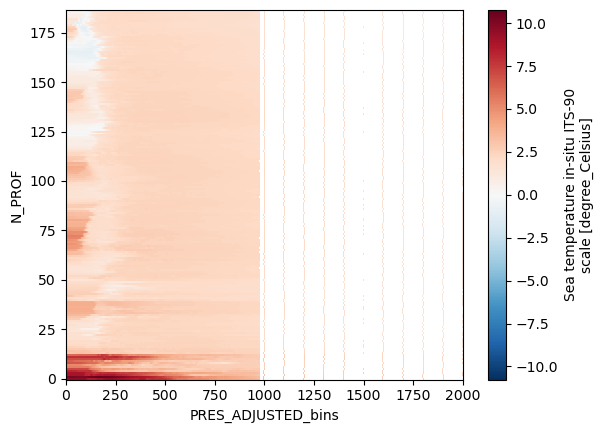

In [6]:
binned_ds.temp.plot()

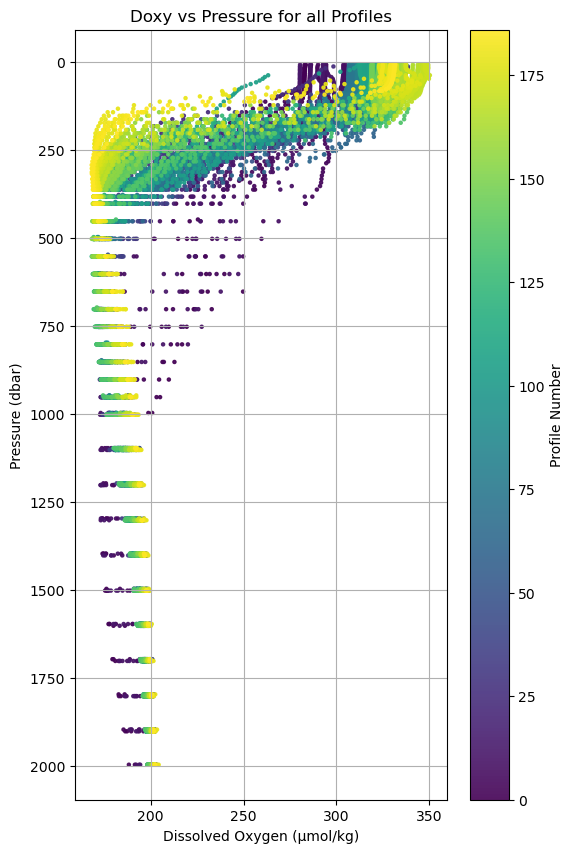

In [7]:
import matplotlib.pyplot as plt

# First, define bin_centers
bin_edges = np.arange(0, 2005, 5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Now plot
plt.figure(figsize=(6,10))
plt.scatter(
    binned_ds.doxy.values.flatten(),                # x-axis: DOXY
    np.tile(bin_centers, binned_ds.doxy.shape[0]),   # y-axis: Pressure
    c=np.repeat(np.arange(binned_ds.doxy.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
plt.grid()
plt.gca().invert_yaxis()  # Pressure increases downward
plt.xlabel('Dissolved Oxygen (μmol/kg)')
plt.ylabel('Pressure (dbar)')
plt.colorbar(label='Profile Number')
plt.title('Doxy vs Pressure for all Profiles')
plt.show()


# And make a T/S Diagram 

In [8]:
binned_ds

<xarray.Dataset>
Dimensions:             (PRES_ADJUSTED_bins: 400, N_PROF: 187)
Coordinates:
  * PRES_ADJUSTED_bins  (PRES_ADJUSTED_bins) float64 2.5 7.5 ... 1.998e+03
Dimensions without coordinates: N_PROF
Data variables:
    psal                (N_PROF, PRES_ADJUSTED_bins) float32 34.1 34.1 ... 34.71
    temp                (N_PROF, PRES_ADJUSTED_bins) float32 9.547 ... 0.9603
    latitude            (N_PROF) float64 -46.01 -46.77 -47.86 ... -61.5 -61.68
    longitude           (N_PROF) float64 85.62 85.84 87.67 ... 146.7 147.1 147.9
    time                (N_PROF) datetime64[ns] 2020-02-16T03:27:58 ... 2025-...
    nitrate             (N_PROF, PRES_ADJUSTED_bins) float32 nan 13.87 ... 32.06
    doxy                (N_PROF, PRES_ADJUSTED_bins) float32 nan 283.6 ... 202.5

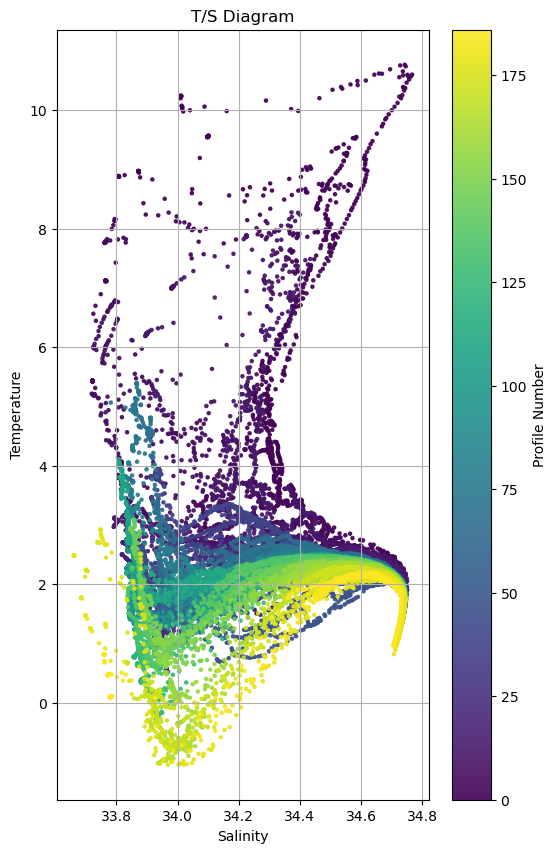

In [9]:
# First, define bin_centers
bin_edges = np.arange(0, 2005, 5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Now plot
plt.figure(figsize=(6,10))
plt.scatter(
    binned_ds.psal.values.flatten(),                
    binned_ds.temp.values.flatten(),   
    c=np.repeat(np.arange(binned_ds.doxy.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
plt.grid()
plt.xlabel('Salinity')
plt.ylabel('Temperature')
plt.colorbar(label='Profile Number')
plt.title('T/S Diagram')
plt.show()


# And now we will plot the float location 

In [19]:
!pip install cartopy # you may have to restart this after running this chunk of code

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/56.0 kB ? eta -:--:--
     ---------------------------------------- 56.0/56.0 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.2/11.0 MB 7.3 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/11.0 MB 7.1 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/11.0 MB 8.1 MB/s eta 0:00:02
   ----- ---------------------------------- 1.5/11.0 MB 8.0 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.0 MB 9.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.9/11.0 MB 10.2 MB/s eta 0:00:01
   ------------- -------------------------- 3.8/11.0 MB 11.6 MB/s eta 0:00:01
   ----------------- ---------------------- 4.9/11.0 MB 13.1 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.0 MB 14.8 MB/s eta 0:00:01
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


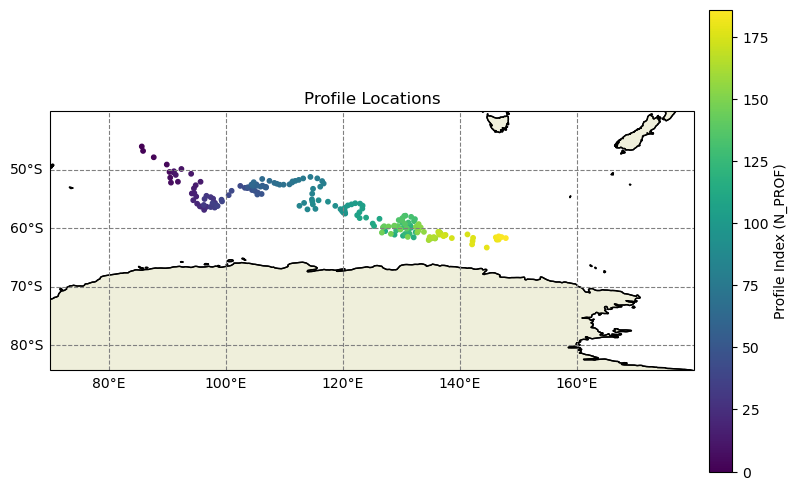

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Make a figure
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land, coastlines
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
ax.coastlines()

# Scatter the lat/lon points and save the scatter object
sc = plt.scatter(
    binned_ds.longitude.values,
    binned_ds.latitude.values,
    c=binned_ds.N_PROF,
    cmap='viridis',
    s=10,
    transform=ccrs.PlateCarree()
)

# Set map extent
ax.set_extent([70, 180, -80, -40])

# Add gridlines and label them
gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

# Add a colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Profile Index (N_PROF)')

# Labels
ax.set_title('Profile Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


# And now lets make a story about this

## T/S Diagram for the first 20 profiles

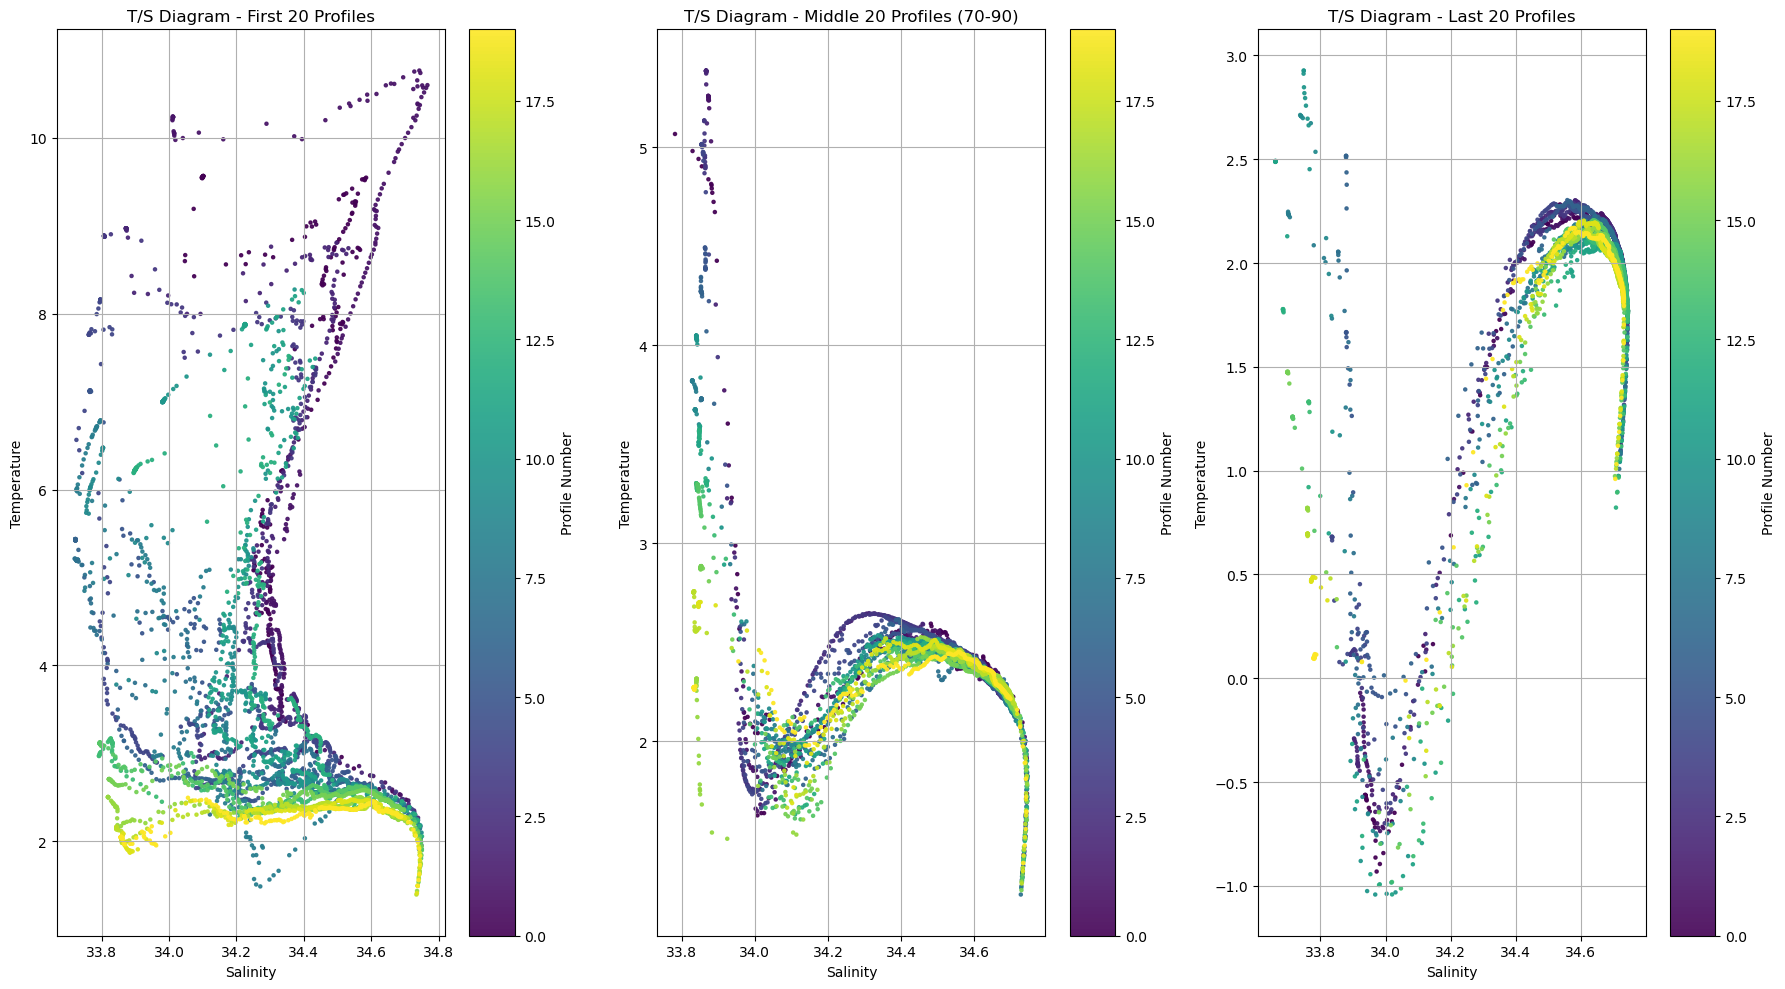

In [11]:
first_20 = binned_ds.isel(N_PROF=slice(0, 20))
last_20 = binned_ds.isel(N_PROF=slice(-20, None))
middle_20 = binned_ds.isel(N_PROF=slice(70, 90))  # Middle 20 profiles from 70 to 90

# Define bin_centers
bin_edges = np.arange(0, 2005, 5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 10))  # Adjusting for 3 subplots

# Plot for the first 20 profiles
axes[0].scatter(
    first_20.psal.values.flatten(),                
    first_20.temp.values.flatten(),   
    c=np.repeat(np.arange(first_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[0].grid()
axes[0].set_xlabel('Salinity')
axes[0].set_ylabel('Temperature')
axes[0].set_title('T/S Diagram - First 20 Profiles')
fig.colorbar(axes[0].collections[0], ax=axes[0], label='Profile Number')

# Plot for the middle 20 profiles
axes[1].scatter(
    middle_20.psal.values.flatten(),                
    middle_20.temp.values.flatten(),   
    c=np.repeat(np.arange(middle_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[1].grid()
axes[1].set_xlabel('Salinity')
axes[1].set_ylabel('Temperature')
axes[1].set_title('T/S Diagram - Middle 20 Profiles (70-90)')
fig.colorbar(axes[1].collections[0], ax=axes[1], label='Profile Number')

# Plot for the last 20 profiles
axes[2].scatter(
    last_20.psal.values.flatten(),                
    last_20.temp.values.flatten(),   
    c=np.repeat(np.arange(last_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[2].grid()
axes[2].set_xlabel('Salinity')
axes[2].set_ylabel('Temperature')
axes[2].set_title('T/S Diagram - Last 20 Profiles')
fig.colorbar(axes[2].collections[0], ax=axes[2], label='Profile Number')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


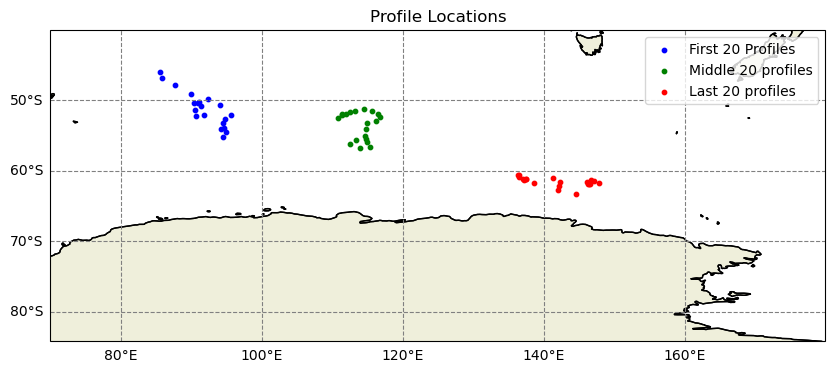

In [12]:
# Make a figure
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land, coastlines
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
ax.coastlines()

# Scatter the lat/lon points and save the scatter object
sc = plt.scatter(
    first_20.longitude.values,
    first_20.latitude.values,
    c='blue', label='First 20 Profiles',
    s=10,
    transform=ccrs.PlateCarree()
)

sc_mid = plt.scatter(
    middle_20.longitude.values,
    middle_20.latitude.values,
    c='green', label='Middle 20 profiles',
    s=10,
    transform=ccrs.PlateCarree()
)

sc_last = plt.scatter(
    last_20.longitude.values,
    last_20.latitude.values,
    c='red', label='Last 20 profiles',
    s=10,
    transform=ccrs.PlateCarree()
)

# Set map extent
ax.set_extent([70, 180, -80, -40])

# Add gridlines and label them
gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False



# Labels
ax.set_title('Profile Locations')
ax.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


# Do the same for Nitrate and DO 

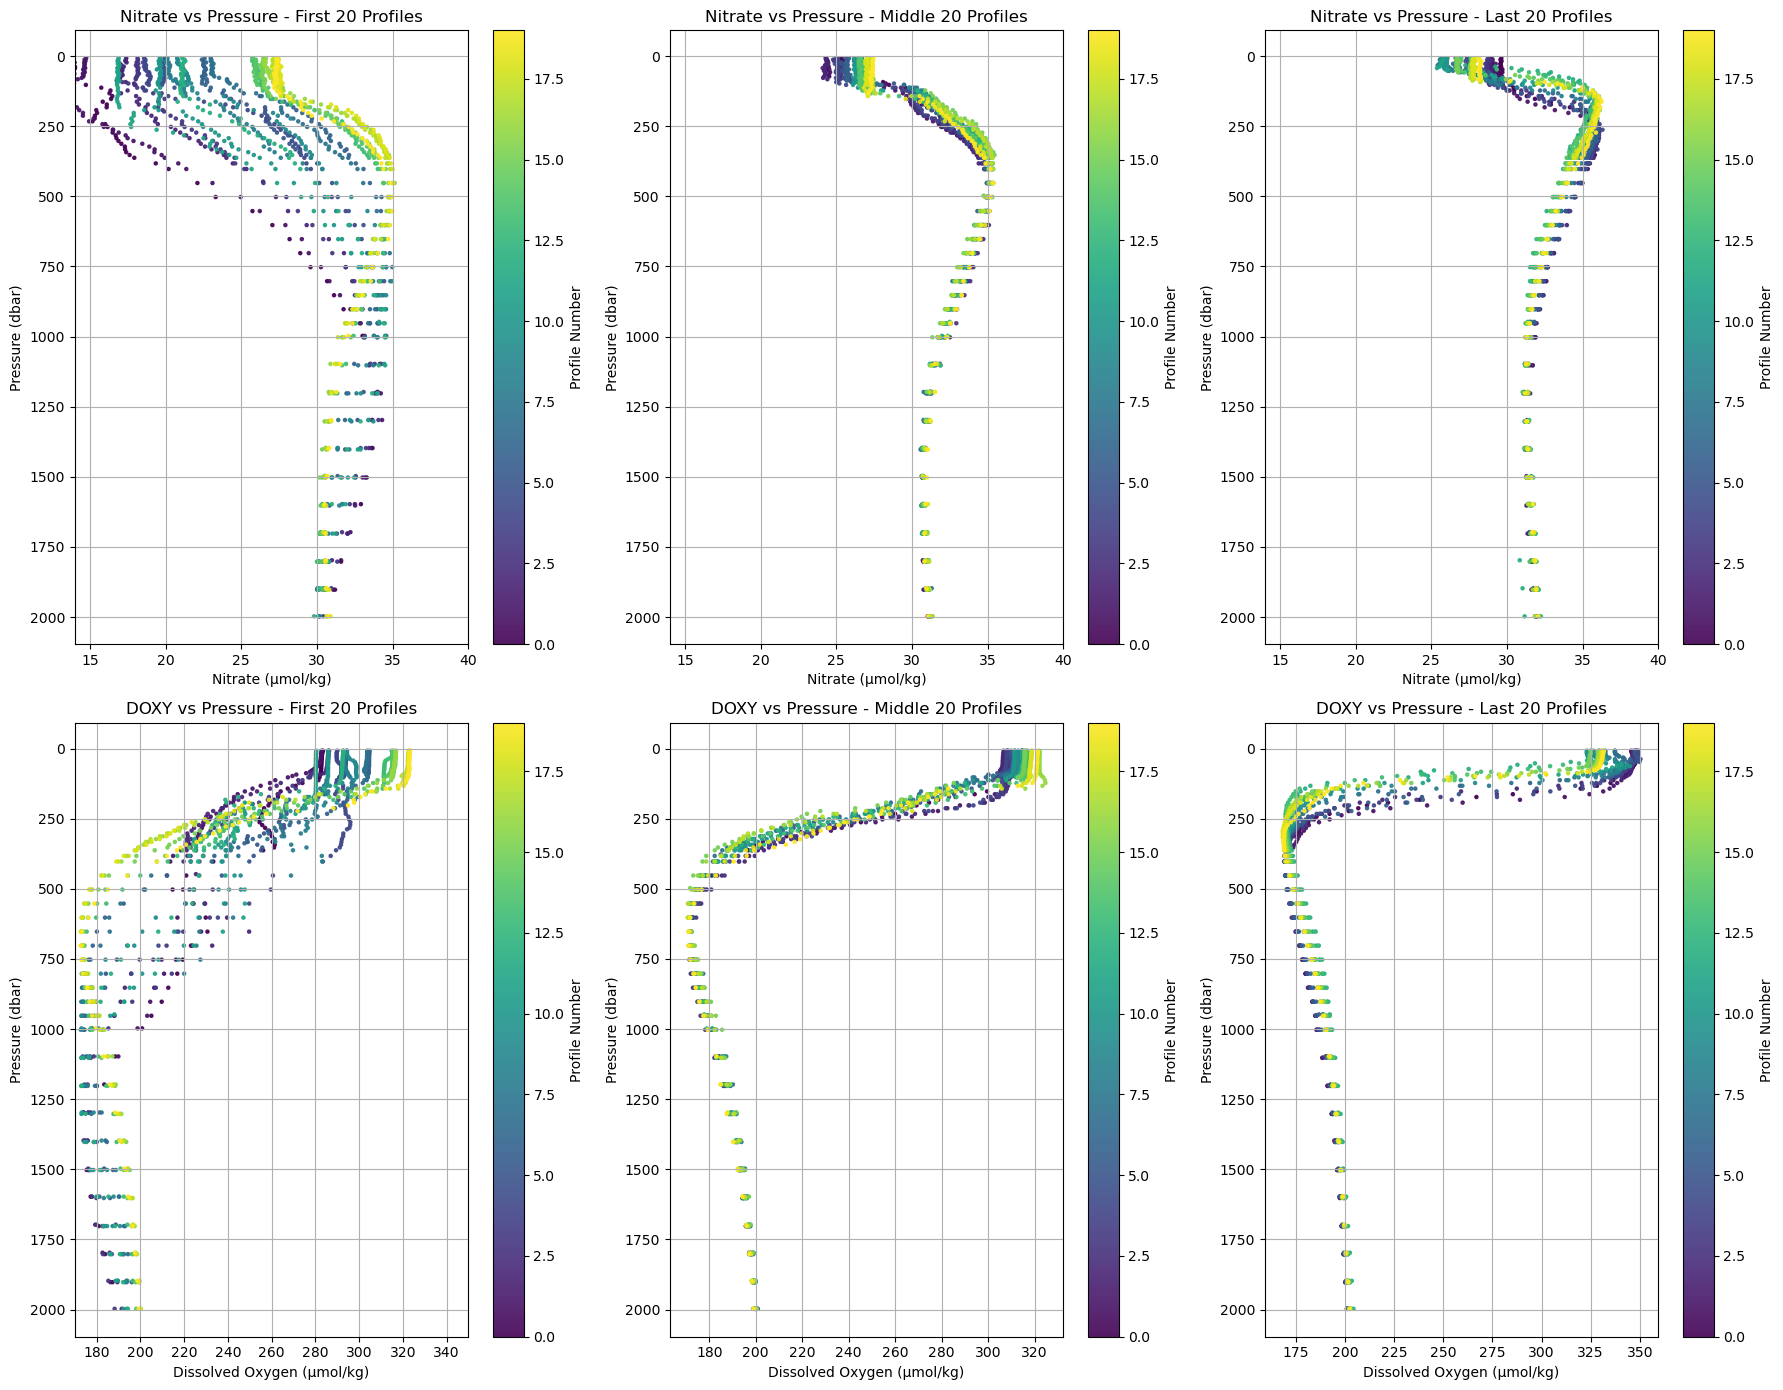

In [13]:
first_20 = binned_ds.isel(N_PROF=slice(0, 20))
middle_20 = binned_ds.isel(N_PROF=slice(70, 90))  # Middle 20 profiles from 70 to 90
last_20 = binned_ds.isel(N_PROF=slice(-20, None))

# Define bin_centers
bin_edges = np.arange(0, 2005, 5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 14))  # 2 rows, 3 columns for pressure vs. nitrate and DO

# Plot Pressure vs Nitrate for First 20 profiles
axes[0, 0].scatter(
    first_20.nitrate.values.flatten(),                # x-axis: Nitrate
    np.tile(bin_centers, first_20.nitrate.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(first_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[0, 0].grid()
axes[0, 0].invert_yaxis()  # Pressure increases downward
axes[0, 0].set_xlabel('Nitrate (μmol/kg)')
axes[0, 0].set_ylabel('Pressure (dbar)')
axes[0, 0].set_title('Nitrate vs Pressure - First 20 Profiles')
fig.colorbar(axes[0, 0].collections[0], ax=axes[0, 0], label='Profile Number')

# Plot Pressure vs Nitrate for Middle 20 profiles
axes[0, 1].scatter(
    middle_20.nitrate.values.flatten(),                # x-axis: Nitrate
    np.tile(bin_centers, middle_20.nitrate.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(middle_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[0, 1].grid()
axes[0, 1].invert_yaxis()  # Pressure increases downward
axes[0, 1].set_xlabel('Nitrate (μmol/kg)')
axes[0, 1].set_ylabel('Pressure (dbar)')
axes[0, 1].set_title('Nitrate vs Pressure - Middle 20 Profiles')
fig.colorbar(axes[0, 1].collections[0], ax=axes[0, 1], label='Profile Number')

# Plot Pressure vs Nitrate for Last 20 profiles
axes[0, 2].scatter(
    last_20.nitrate.values.flatten(),                # x-axis: Nitrate
    np.tile(bin_centers, last_20.nitrate.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(last_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[0, 2].grid()
axes[0, 2].invert_yaxis()  # Pressure increases downward
axes[0, 2].set_xlabel('Nitrate (μmol/kg)')
axes[0, 2].set_ylabel('Pressure (dbar)')
axes[0, 2].set_title('Nitrate vs Pressure - Last 20 Profiles')
fig.colorbar(axes[0, 2].collections[0], ax=axes[0, 2], label='Profile Number')

# Plot Pressure vs DO for First 20 profiles
axes[1, 0].scatter(
    first_20.doxy.values.flatten(),                # x-axis: DOXY
    np.tile(bin_centers, first_20.doxy.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(first_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[1, 0].grid()
axes[1, 0].invert_yaxis()  # Pressure increases downward
axes[1, 0].set_xlabel('Dissolved Oxygen (μmol/kg)')
axes[1, 0].set_ylabel('Pressure (dbar)')
axes[1, 0].set_title('DOXY vs Pressure - First 20 Profiles')
fig.colorbar(axes[1, 0].collections[0], ax=axes[1, 0], label='Profile Number')

# Plot Pressure vs DO for Middle 20 profiles
axes[1, 1].scatter(
    middle_20.doxy.values.flatten(),                # x-axis: DOXY
    np.tile(bin_centers, middle_20.doxy.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(middle_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[1, 1].grid()
axes[1, 1].invert_yaxis()  # Pressure increases downward
axes[1, 1].set_xlabel('Dissolved Oxygen (μmol/kg)')
axes[1, 1].set_ylabel('Pressure (dbar)')
axes[1, 1].set_title('DOXY vs Pressure - Middle 20 Profiles')
fig.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Profile Number')

# Plot Pressure vs DO for Last 20 profiles
axes[1, 2].scatter(
    last_20.doxy.values.flatten(),                # x-axis: DOXY
    np.tile(bin_centers, last_20.doxy.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(last_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[1, 2].grid()
axes[1, 2].invert_yaxis()  # Pressure increases downward
axes[1, 2].set_xlabel('Dissolved Oxygen (μmol/kg)')
axes[1, 2].set_ylabel('Pressure (dbar)')
axes[1, 2].set_title('DOXY vs Pressure - Last 20 Profiles')
fig.colorbar(axes[1, 2].collections[0], ax=axes[1, 2], label='Profile Number')

axes[0, 0].set_xlim(14, 40)  # Set xlim for Nitrate
axes[0, 1].set_xlim(14, 40)  
axes[0, 2].set_xlim(14, 40)  
axes[1, 0].set_xlim(170, 350)  # Set xlim for Doxy
axes[1, 0].set_xlim(170, 350)  
axes[1, 0].set_xlim(170, 350)  


# Adjust layout and show the plot
plt.tight_layout()
plt.show()


## What is happening with the time to explain the variation in T/S?

In [14]:
first_20.time

<xarray.DataArray 'time' (N_PROF: 20)>
array(['2020-02-16T03:27:58.000000000', '2020-02-26T10:51:48.000000000',
       '2020-03-07T18:23:18.000000000', '2020-03-18T01:12:35.000000000',
       '2020-03-28T08:19:16.000000000', '2020-04-07T15:42:42.000000000',
       '2020-04-17T23:13:32.000000000', '2020-04-28T06:15:26.000000000',
       '2020-05-08T13:24:13.000000000', '2020-05-18T20:56:59.000000000',
       '2020-05-29T04:34:20.000000000', '2020-06-08T11:52:10.000000000',
       '2020-06-18T18:54:11.000000000', '2020-06-29T02:04:24.000000000',
       '2020-07-09T09:23:09.000000000', '2020-07-19T17:02:49.000000000',
       '2020-07-30T03:59:57.000000000', '2020-08-09T15:09:31.000000000',
       '2020-08-20T02:29:46.000000000', '2020-08-30T11:13:40.000000000'],
      dtype='datetime64[ns]')
Dimensions without coordinates: N_PROF

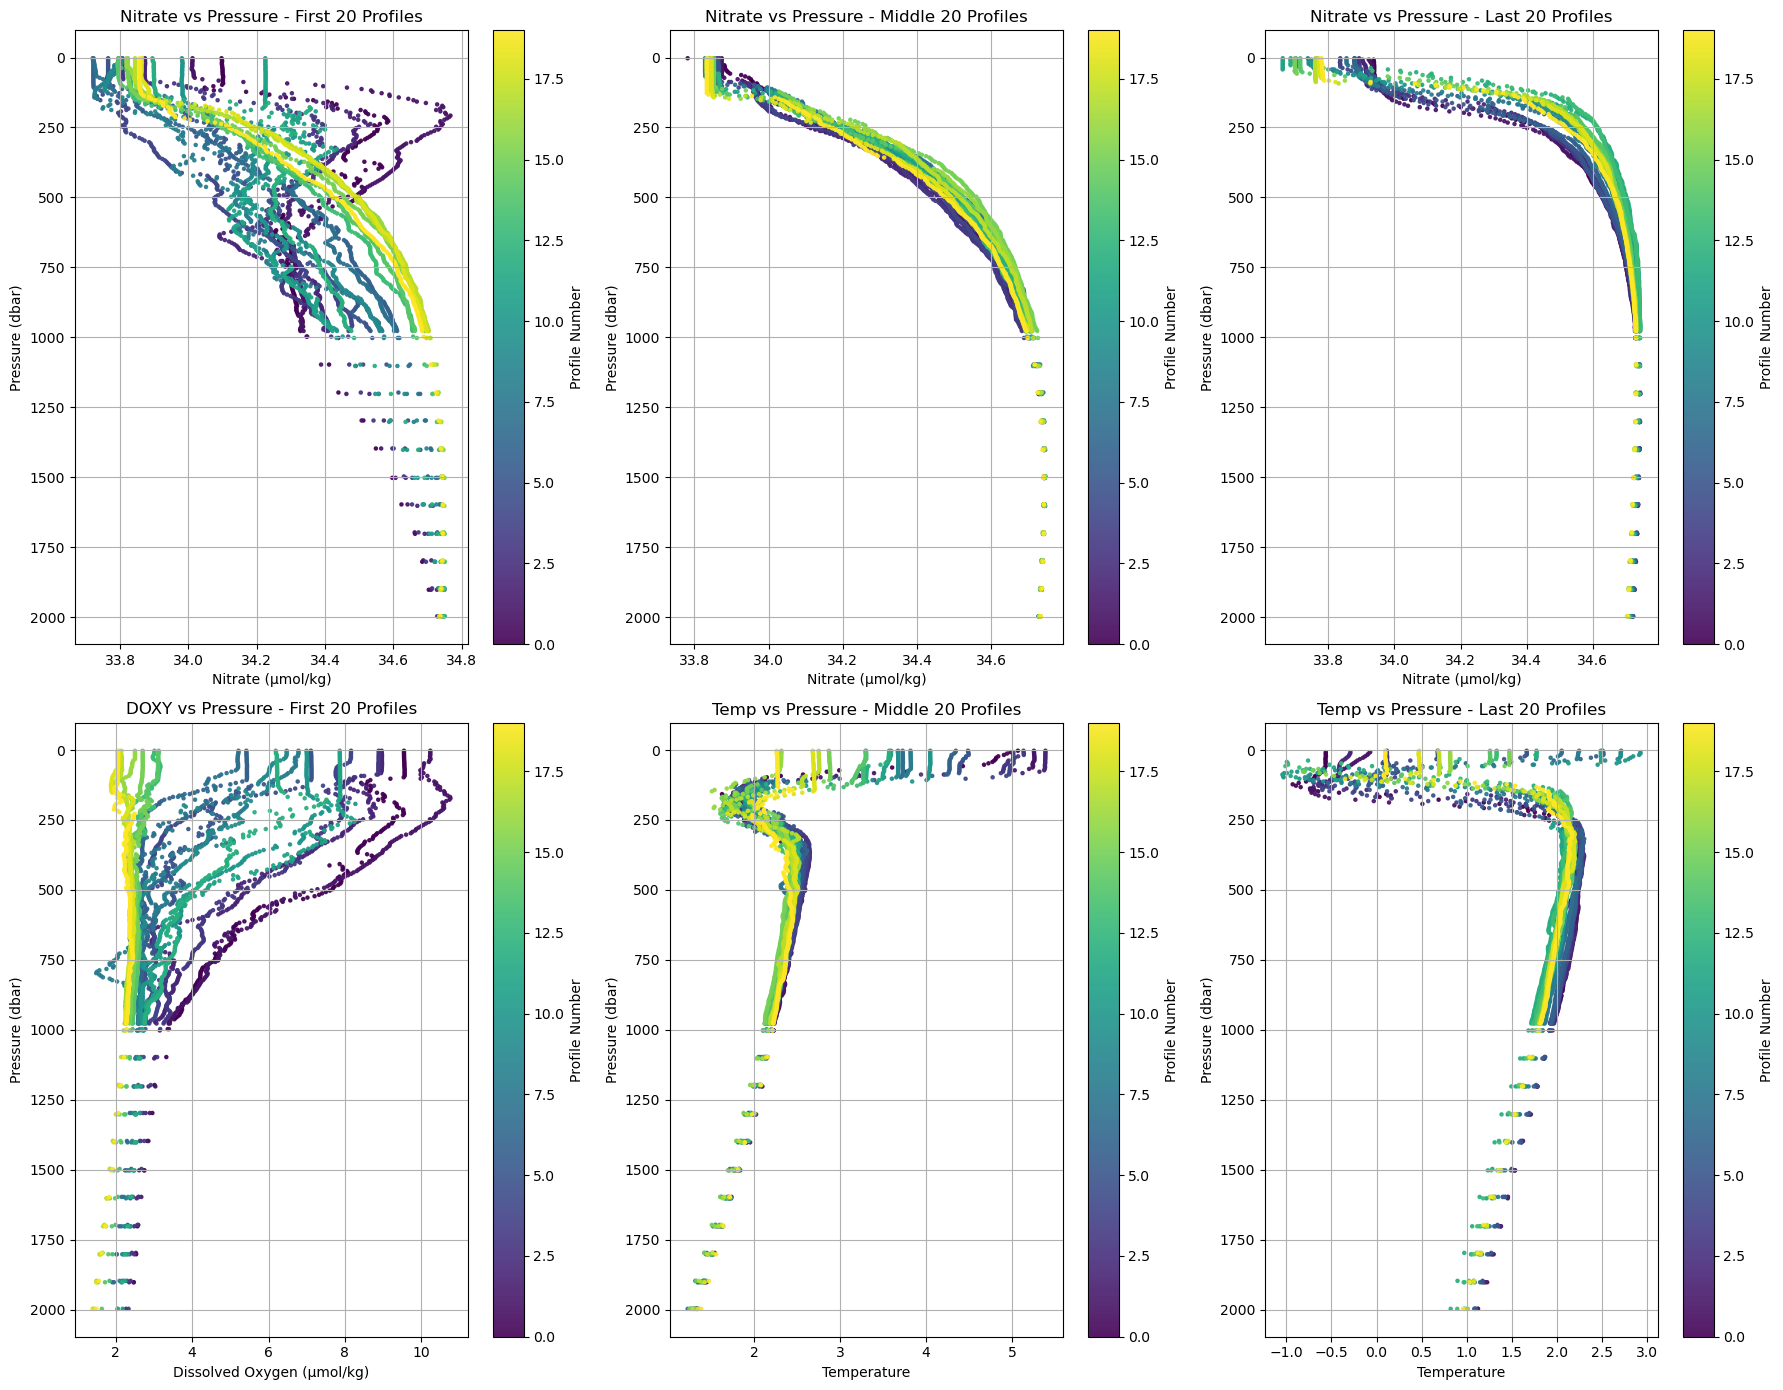

In [15]:
first_20 = binned_ds.isel(N_PROF=slice(0, 20))
middle_20 = binned_ds.isel(N_PROF=slice(70, 90))  # Middle 20 profiles from 70 to 90
last_20 = binned_ds.isel(N_PROF=slice(-20, None))

# Define bin_centers
bin_edges = np.arange(0, 2005, 5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 14))  # 2 rows, 3 columns for pressure vs. nitrate and DO

# Plot Pressure vs Nitrate for First 20 profiles
axes[0, 0].scatter(
    first_20.psal.values.flatten(),                # x-axis: Nitrate
    np.tile(bin_centers, first_20.nitrate.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(first_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[0, 0].grid()
axes[0, 0].invert_yaxis()  # Pressure increases downward
axes[0, 0].set_xlabel('Nitrate (μmol/kg)')
axes[0, 0].set_ylabel('Pressure (dbar)')
axes[0, 0].set_title('Nitrate vs Pressure - First 20 Profiles')
fig.colorbar(axes[0, 0].collections[0], ax=axes[0, 0], label='Profile Number')

# Plot Pressure vs Nitrate for Middle 20 profiles
axes[0, 1].scatter(
    middle_20.psal.values.flatten(),                # x-axis: Nitrate
    np.tile(bin_centers, middle_20.nitrate.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(middle_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[0, 1].grid()
axes[0, 1].invert_yaxis()  # Pressure increases downward
axes[0, 1].set_xlabel('Nitrate (μmol/kg)')
axes[0, 1].set_ylabel('Pressure (dbar)')
axes[0, 1].set_title('Nitrate vs Pressure - Middle 20 Profiles')
fig.colorbar(axes[0, 1].collections[0], ax=axes[0, 1], label='Profile Number')

# Plot Pressure vs Nitrate for Last 20 profiles
axes[0, 2].scatter(
    last_20.psal.values.flatten(),                # x-axis: Nitrate
    np.tile(bin_centers, last_20.nitrate.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(last_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[0, 2].grid()
axes[0, 2].invert_yaxis()  # Pressure increases downward
axes[0, 2].set_xlabel('Nitrate (μmol/kg)')
axes[0, 2].set_ylabel('Pressure (dbar)')
axes[0, 2].set_title('Nitrate vs Pressure - Last 20 Profiles')
fig.colorbar(axes[0, 2].collections[0], ax=axes[0, 2], label='Profile Number')

# Plot Pressure vs DO for First 20 profiles
axes[1, 0].scatter(
    first_20.temp.values.flatten(),                # x-axis: DOXY
    np.tile(bin_centers, first_20.doxy.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(first_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[1, 0].grid()
axes[1, 0].invert_yaxis()  # Pressure increases downward
axes[1, 0].set_xlabel('Dissolved Oxygen (μmol/kg)')
axes[1, 0].set_ylabel('Pressure (dbar)')
axes[1, 0].set_title('DOXY vs Pressure - First 20 Profiles')
fig.colorbar(axes[1, 0].collections[0], ax=axes[1, 0], label='Profile Number')

# Plot Pressure vs DO for Middle 20 profiles
axes[1, 1].scatter(
    middle_20.temp.values.flatten(),                # x-axis: DOXY
    np.tile(bin_centers, middle_20.doxy.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(middle_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[1, 1].grid()
axes[1, 1].invert_yaxis()  # Pressure increases downward
axes[1, 1].set_xlabel('Temperature')
axes[1, 1].set_ylabel('Pressure (dbar)')
axes[1, 1].set_title('Temp vs Pressure - Middle 20 Profiles')
fig.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Profile Number')

# Plot Pressure vs DO for Last 20 profiles
axes[1, 2].scatter(
    last_20.temp.values.flatten(),                # x-axis: DOXY
    np.tile(bin_centers, last_20.doxy.shape[0]),  # y-axis: Pressure
    c=np.repeat(np.arange(last_20.N_PROF.shape[0]), len(bin_centers)),  # color by profile
    cmap='viridis',
    s=5,
    alpha=0.9
)
axes[1, 2].grid()
axes[1, 2].invert_yaxis()  # Pressure increases downward
axes[1, 2].set_xlabel('Temperature')
axes[1, 2].set_ylabel('Pressure (dbar)')
axes[1, 2].set_title('Temp vs Pressure - Last 20 Profiles')
fig.colorbar(axes[1, 2].collections[0], ax=axes[1, 2], label='Profile Number')

# axes[0, 0].set_xlim(14, 40)  # Set xlim for Nitrate
# axes[0, 1].set_xlim(14, 40)  
# axes[0, 2].set_xlim(14, 40)  
# axes[1, 0].set_xlim(170, 350)  # Set xlim for Doxy
# axes[1, 0].set_xlim(170, 350)  
# axes[1, 0].set_xlim(170, 350)  


# Adjust layout and show the plot
plt.tight_layout()
plt.show()


# Now its time to try and create your own story! Find a Float, and see if you can work out what is happening along its path. you can also add in other variables like pH, backscatter and Chlorophyll if you want - just ask! The code below should load in all the variables the float has

In [ ]:
save_directory = r'argo_profiles_2/'  # this will make a new folder called argo profiles in your directory and save the data there
root = r'argo_profiles_2/'
# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

wmoids, gdac_subset, downloaded_files = argo_gdac(
    floats=[],              # Float ID #############ENTER YOUR NEW FLOAT PROFILE NUMBER HERE #########################
    skip_download=False,           # Actually download the files
    download_individual_profs=True, # Download individual profiles (not one big Sprof file)
    save_to=save_directory,         # Save location
    verbose=True                    # Print status updates
)

In [69]:
import xarray as xr
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# Define bin edges for pressure
bin_edges = np.arange(0, 2005, 5)  # 5 dbar bins up to 2000 dbar
pres_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # Used as coordinate later

# Function to bin data
def bin_data(data, pressure, bin_edges):
    mask = np.isfinite(pressure) & np.isfinite(data)
    if not mask.any():
        return None  # No valid data
    data = data.where(mask)
    pressure = pressure.where(mask)
    binned = data.groupby_bins(pressure, bin_edges).mean(dim="N_LEVELS", skipna=True)
    if np.isnan(binned).all():
        return None  # All binned values are NaN
    return binned

# Dictionary to store binned variable lists dynamically
binned_data_dict = {}
lat_list = []
lon_list = []
time_list = []

# Folder and file list
save_directory = './argo_profiles_5/'  ####################### ADJUST THIS #########################
files = sorted([f for f in os.listdir(save_directory) if f.endswith('.nc')])

for filepath in tqdm(files, desc="Processing Argo profiles"):
    try:
        file_full_path = os.path.join(save_directory, filepath)
        ds = xr.open_dataset(file_full_path)

        n_prof = ds.dims.get('N_PROF', 1)  # Default to 1 if missing

        for i in range(n_prof):
            try:
                # Get pressure
                pressure = ds.get('PRES_ADJUSTED', ds.get('PRES')).isel(N_PROF=i)
                if pressure.max(skipna=True).values < 1000:
                    continue  # Skip shallow profiles

                # Metadata
                lat = ds.LATITUDE.isel(N_PROF=i).values
                lon = ds.LONGITUDE.isel(N_PROF=i).values
                time = ds.JULD.isel(N_PROF=i).values
                if np.issubdtype(time.dtype, np.datetime64):
                    time = time.astype('datetime64[s]').astype(float)
                else:
                    time = pd.to_datetime(str(time)).to_datetime64().astype('datetime64[s]').astype(float)

                # Track which base vars we've already added
                added_vars = set()

                # Loop over all *_ADJUSTED variables
                for varname in ds.data_vars:
                    if not varname.endswith("_ADJUSTED"):
                        continue

                    var_data = ds[varname].isel(N_PROF=i)
                    binned = bin_data(var_data, pressure, bin_edges)
                    if binned is None:
                        continue  # Skip variables with no valid binned data

                    if varname not in binned_data_dict:
                        binned_data_dict[varname] = []
                    binned_data_dict[varname].append(binned)
                    added_vars.add(varname.split("_")[0])

                # TEMP and PSAL fallback
                for base_var in ['TEMP', 'PSAL']:
                    if base_var in added_vars:
                        continue  # Already included via *_ADJUSTED
                    var_data = ds.get(f"{base_var}_ADJUSTED", ds.get(base_var))
                    if var_data is None:
                        continue
                    binned = bin_data(var_data.isel(N_PROF=i), pressure, bin_edges)
                    if binned is None:
                        continue
                    key = f"{base_var}_ADJUSTED"
                    if key not in binned_data_dict:
                        binned_data_dict[key] = []
                    binned_data_dict[key].append(binned)

                # Save metadata
                lat_list.append(np.array([lat]))
                lon_list.append(np.array([lon]))
                time_list.append(np.array([time]))

            except Exception as e:
                print(f"Skipping profile {i} in {filepath} due to error: {e}")

    except Exception as e:
        print(f"Skipping file {filepath} due to error: {e}")

# --- Build Dataset ---
valid_vars = {var: xr.concat(binned_data_dict[var], dim='N_PROF') for var in binned_data_dict if len(binned_data_dict[var]) > 0}

if valid_vars:
    binned_ds = xr.Dataset(valid_vars)

    # Add coordinates
    binned_ds['latitude'] = ('N_PROF', np.concatenate(lat_list))
    binned_ds['longitude'] = ('N_PROF', np.concatenate(lon_list))
    epoch = np.datetime64('1970-01-01T00:00:00Z')
    binned_ds['time'] = ('N_PROF', epoch + np.array(time_list).flatten().astype('timedelta64[s]'))

    # Add pressure bin centers
    binned_ds = binned_ds.assign_coords({"PRES_ADJUSTED_bins": pres_bin_centers})

    print("✅ Processing complete!")
    print(binned_ds)
else:
    print("⚠️ No valid data was processed. Dataset is empty.")


Processing Argo profiles:   0%|                                                                 | 0/42 [00:00<?, ?it/s]C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_30868\400988024.py:38: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_prof = ds.dims.get('N_PROF', 1)  # Default to 1 if missing
Processing Argo profiles:   2%|█▎                                                       | 1/42 [00:00<00:29,  1.41it/s]C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_30868\400988024.py:38: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_prof = ds.dims.get('N_PROF', 1)  # Default to 1 if missing
Proces

✅ Processing complete!
<xarray.Dataset> Size: 609kB
Dimensions:                     (N_PROF: 42, PRES_ADJUSTED_bins: 400)
Coordinates:
  * PRES_ADJUSTED_bins          (PRES_ADJUSTED_bins) float64 3kB 2.5 ... 1.99...
Dimensions without coordinates: N_PROF
Data variables:
    PRES_ADJUSTED               (N_PROF, PRES_ADJUSTED_bins) float32 67kB 3.3...
    TEMP_ADJUSTED               (N_PROF, PRES_ADJUSTED_bins) float32 67kB 4.4...
    PSAL_ADJUSTED               (N_PROF, PRES_ADJUSTED_bins) float32 67kB 33....
    DOXY_ADJUSTED               (N_PROF, PRES_ADJUSTED_bins) float32 67kB 320...
    CHLA_ADJUSTED               (N_PROF, PRES_ADJUSTED_bins) float32 67kB 0.7...
    CHLA_FLUORESCENCE_ADJUSTED  (N_PROF, PRES_ADJUSTED_bins) float32 67kB 1.2...
    BBP700_ADJUSTED             (N_PROF, PRES_ADJUSTED_bins) float32 67kB 0.0...
    PH_IN_SITU_TOTAL_ADJUSTED   (N_PROF, PRES_ADJUSTED_bins) float32 67kB 8.0...
    NITRATE_ADJUSTED            (N_PROF, PRES_ADJUSTED_bins) float32 67kB nan...


C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_30868\400988024.py:109: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  epoch = np.datetime64('1970-01-01T00:00:00Z')
C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_30868\400988024.py:110: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  binned_ds['time'] = ('N_PROF', epoch + np.array(time_list).flatten().astype('timedelta64[s]'))
C:\Users\jkwyatt\AppData\Local\Temp\ipykernel_30868\400988024.py:110: UserWarning: Converting non-nanosecond precision datetime values to nanosecond preci